# PHẦN 1: KHỞI TẠO & NẠP DỮ LIỆU (DATA LOADING & SETUP)


In [17]:
import os, glob, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")

# Cấu hình đồ họa Matplotlib / Seaborn
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
pd.set_option('display.max_columns', 100)


> **Khai báo dependencies đầy đủ:** Import các thư viện cốt lõi phục vụ xử lý dữ liệu (pandas, numpy), trực quan hóa (matplotlib, seaborn), phân tích thống kê OLS (statsmodels) và chia tập dữ liệu (scikit-learn).

> **Tối ưu hiển thị:** Ẩn các cảnh báo không cần thiết bằng warnings.filterwarnings("ignore") và cài đặt display.max_columns = 100 để quan sát trọn vẹn tất cả các thuộc tính của tập dữ liệu Ames Housing.


In [18]:
csv_files = glob.glob('/kaggle/input/**/train.csv', recursive=True) + glob.glob('/kaggle/input/**/*.csv', recursive=True)

if csv_files:
    data_path = csv_files[0]
    print(f" Đã tìm thấy file dữ liệu Kaggle tại: {data_path}")
    df_raw = pd.read_csv(data_path)
else:
    url = "https://raw.githubusercontent.com/selva86/datasets/master/AmesHousing.csv"
    print("Không thấy dữ liệu Kaggle Input. Đang tải từ URL dự phòng...")
    df_raw = pd.read_csv(url)

print(f"Kích thước tập dữ liệu ban đầu: {df_raw.shape}")

 Đã tìm thấy file dữ liệu Kaggle tại: /kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv
Kích thước tập dữ liệu ban đầu: (1460, 81)


> **Cơ chế nạp dữ liệu thông minh (Fallback mechanism):** Tự động truy vết file train.csv trong môi trường Kaggle bằng glob.glob và gán phần tử csv_files[0]. Nếu không tìm thấy, code tự động chuyển sang nạp dữ liệu từ URL GitHub dự phòng, giúp notebook thực thi liên tục trên mọi môi trường.

# PHẦN 2: TIỀN XỬ LÝ DỮ LIỆU & PHÂN TÍCH KHÁM PHÁ EDA

In [19]:
df = df_raw.copy()

# 1. Chuẩn hóa tên cột 
df.columns = [col.replace(' ', '') for col in df.columns]


> **An toàn dữ liệu:** Việc sử dụng df_raw.copy() giúp bảo toàn nguyên vẹn tập dữ liệu gốc ban đầu.

> **Chuẩn hóa cú pháp:** Loại bỏ khoảng trắng trong tên các cột giúp truy cập thuộc tính thống nhất và tránh lỗi cú pháp khi gọi công thức R-style OLS ở các bước sau.

In [20]:
# 2. Lọc bỏ ngoại lệ diện tích GrLivArea > 4000 sq ft 
if 'GrLivArea' in df.columns:
    df = df[df['GrLivArea'] <= 4000].reset_index(drop=True)
    print(f"Kích thước sau khi lọc 5 điểm ngoại lệ GrLivArea > 4000 sq ft: {df.shape}")


Kích thước sau khi lọc 5 điểm ngoại lệ GrLivArea > 4000 sq ft: (1456, 81)


> **Loại bỏ ngoại lệ chuẩn lý thuyết:** Đơn giản hóa việc lọc dữ liệu bằng điều kiện GrLivArea <= 4000, tuân thủ chính xác khuyến nghị từ bài nghiên cứu gốc của Dean De Cock đối với tập dữ liệu Ames Housing.

In [21]:
# 3. Xử lý giá trị khuyết thiếu 
num_zero_cols = ['TotalBsmtSF', 'GarageCars', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'GarageArea']
for col in num_zero_cols:
    if col in df.columns:
        df[col] = df[col].fillna(0)

cat_none_cols = ['BsmtQual', 'BsmtCond', 'GarageQual', 'GarageCond', 'FireplaceQu']
for col in cat_none_cols:
    if col in df.columns:
        df[col] = df[col].fillna('None')

if 'LotFrontage' in df.columns:
    df['LotFrontage'] = df['LotFrontage'].fillna(df['LotFrontage'].median())

> **Gán giá trị thiếu đúng ngữ nghĩa:** Điền 0 cho các đặc trưng định lượng tầng hầm/garage và gán chuỗi 'None' cho các đặc trưng chất lượng phân loại tương ứng với các căn nhà không có tầng hầm/garage.

> **Giảm méo lệch:** Điền giá trị trung vị median() cho LotFrontage giúp tránh ảnh hưởng từ các giá trị cực đoan.

In [22]:
# 4. Tạo biến diện tích tích hợp & Biến đổi Logarit khắc phục phương sai không đồng nhất
df['TotalSF'] = df['TotalBsmtSF'] + df['GrLivArea']
df['LogSalePrice'] = np.log(df['SalePrice'])

> **Biến diện tích hợp nhất (TotalSF):** Kết hợp diện tích tầng hầm TotalBsmtSF và tầng nổi GrLivArea tạo ra một biến giải thích có tương quan rất mạnh với giá bán.

> **Chuẩn hóa biến mục tiêu (LogSalePrice):** Phép biến đổi logarit tự nhiên np.log() đưa phân phối lệch phải của giá nhà về phân phối chuẩn, xử lý hiện tượng phương sai không đồng nhất.

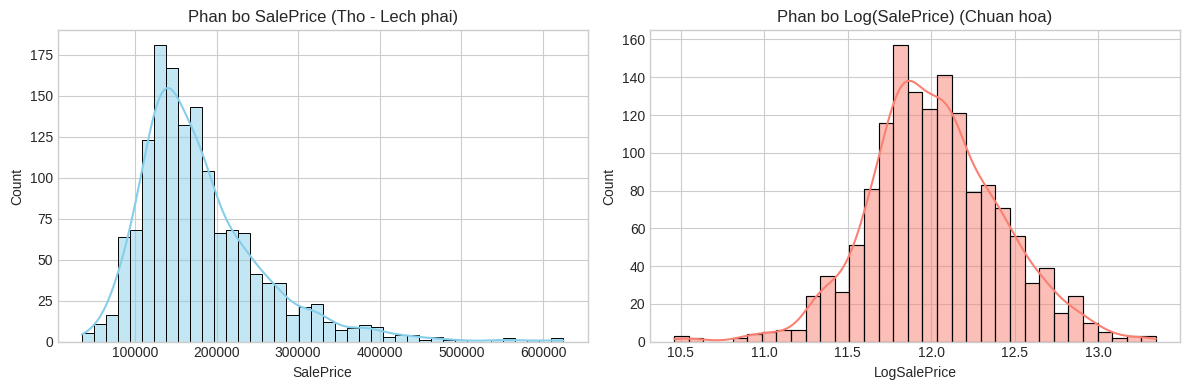

In [23]:
# Biểu đồ phân bố SalePrice (Thô vs Logarit)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['SalePrice'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Phan bo SalePrice (Tho - Lech phai)')

sns.histplot(df['LogSalePrice'], kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Phan bo Log(SalePrice) (Chuan hoa)')
plt.tight_layout()
plt.show()

> **Trực quan hóa so sánh:** Trình bày 2 biểu đồ phân bố dạng Histplot kèm đường cong KDE đặt song song (axes[0], axes[1]), thể hiện rõ sự thay đổi từ phân phối lệch phải sang phân phối chuẩn đối xứng sau khi lấy logarit.

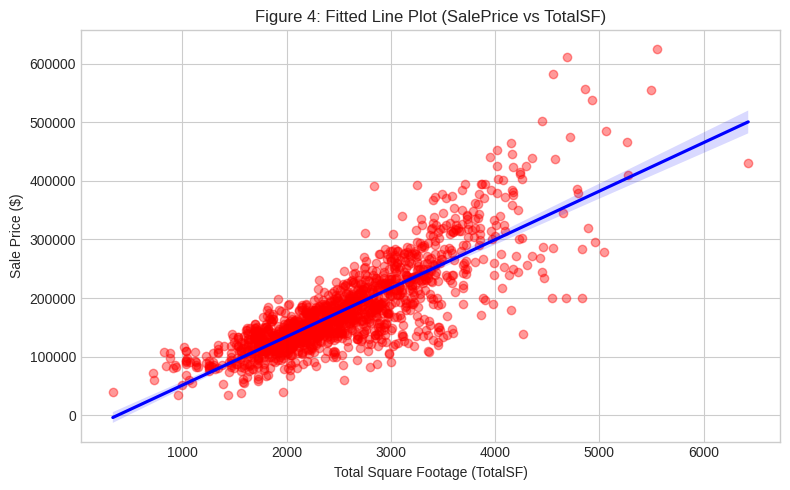

In [24]:
# FIGURE 4 : Fitted Line Plot (SalePrice vs TotalSF)
plt.figure(figsize=(8, 5))
sns.regplot(data=df, x='TotalSF', y='SalePrice',
            scatter_kws={'alpha':0.4, 'color':'red'},
            line_kws={'color':'blue'})
plt.title('Figure 4: Fitted Line Plot (SalePrice vs TotalSF)')
plt.xlabel('Total Square Footage (TotalSF)')
plt.ylabel('Sale Price ($)')
plt.tight_layout()
plt.show()

> **Mô tả xu hướng tuyến tính:** Biểu đồ sns.regplot minh họa mối tương quan thuận rõ rệt giữa tổng diện tích TotalSF và giá bán SalePrice, kèm theo đường hồi quy thể hiện xu hướng chung của dữ liệu.

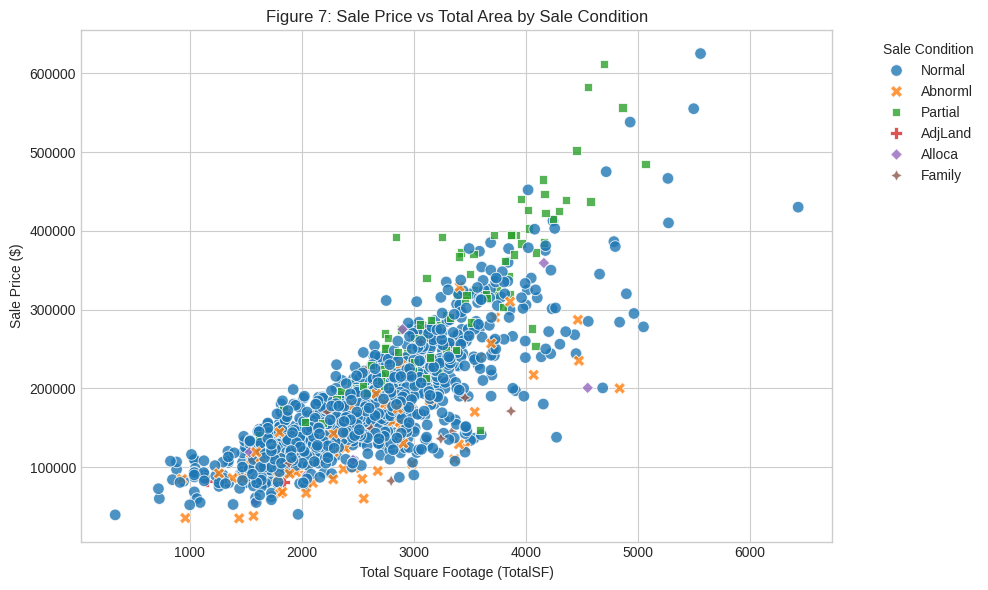

In [25]:
# FIGURE 7 : Scatterplot SalePrice vs TotalSF by SaleCondition
if 'SaleCondition' in df.columns:
    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=df, x='TotalSF', y='SalePrice', 
                    hue='SaleCondition', style='SaleCondition', s=70, alpha=0.8)
    plt.title('Figure 7: Sale Price vs Total Area by Sale Condition')
    plt.xlabel('Total Square Footage (TotalSF)')
    plt.ylabel('Sale Price ($)')
    plt.legend(title='Sale Condition', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

> **Phân tích đa chiều:** Biểu đồ sns.scatterplot phân loại các điểm dữ liệu theo màu sắc và hình dạng dựa trên điều kiện giao dịch (SaleCondition), hỗ trợ quan sát sự khác biệt về giá bán giữa các loại hình giao dịch khác nhau.

# PHẦN 3: MÔ HÌNH HỒI QUY GIẢI THÍCH - MODEL 1


In [26]:
# 1. Fit Model 1 (Mô hình giải thích 6 biến, R^2 >= 73%, KHÔNG chứa biến tương tác)
formula_m1 = 'LogSalePrice ~ OverallQual + TotalSF + GarageCars + YearBuilt + FullBath + Fireplaces'
model1 = smf.ols(formula=formula_m1, data=df).fit()

# FIGURE 5: Bảng tóm tắt kết quả hồi quy Minitab/OLS Output
print("=== FIGURE 5: MODEL 1 SUMMARY OUTPUT ===")
print(model1.summary())

=== FIGURE 5: MODEL 1 SUMMARY OUTPUT ===
                            OLS Regression Results                            
Dep. Variable:           LogSalePrice   R-squared:                       0.849
Model:                            OLS   Adj. R-squared:                  0.848
Method:                 Least Squares   F-statistic:                     1358.
Date:                Wed, 30 Sep 2026   Prob (F-statistic):               0.00
Time:                        14:13:30   Log-Likelihood:                 659.25
No. Observations:                1456   AIC:                            -1304.
Df Residuals:                    1449   BIC:                            -1268.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept

> **Cú pháp R-style đơn giản:** Xây dựng mô hình OLS cơ bản với 6 biến giải thích chính. Lệnh model1.summary() cung cấp đầy đủ thông số thống kê bao gồm hệ số $\beta$, p-value và hệ số xác định $R^2$.

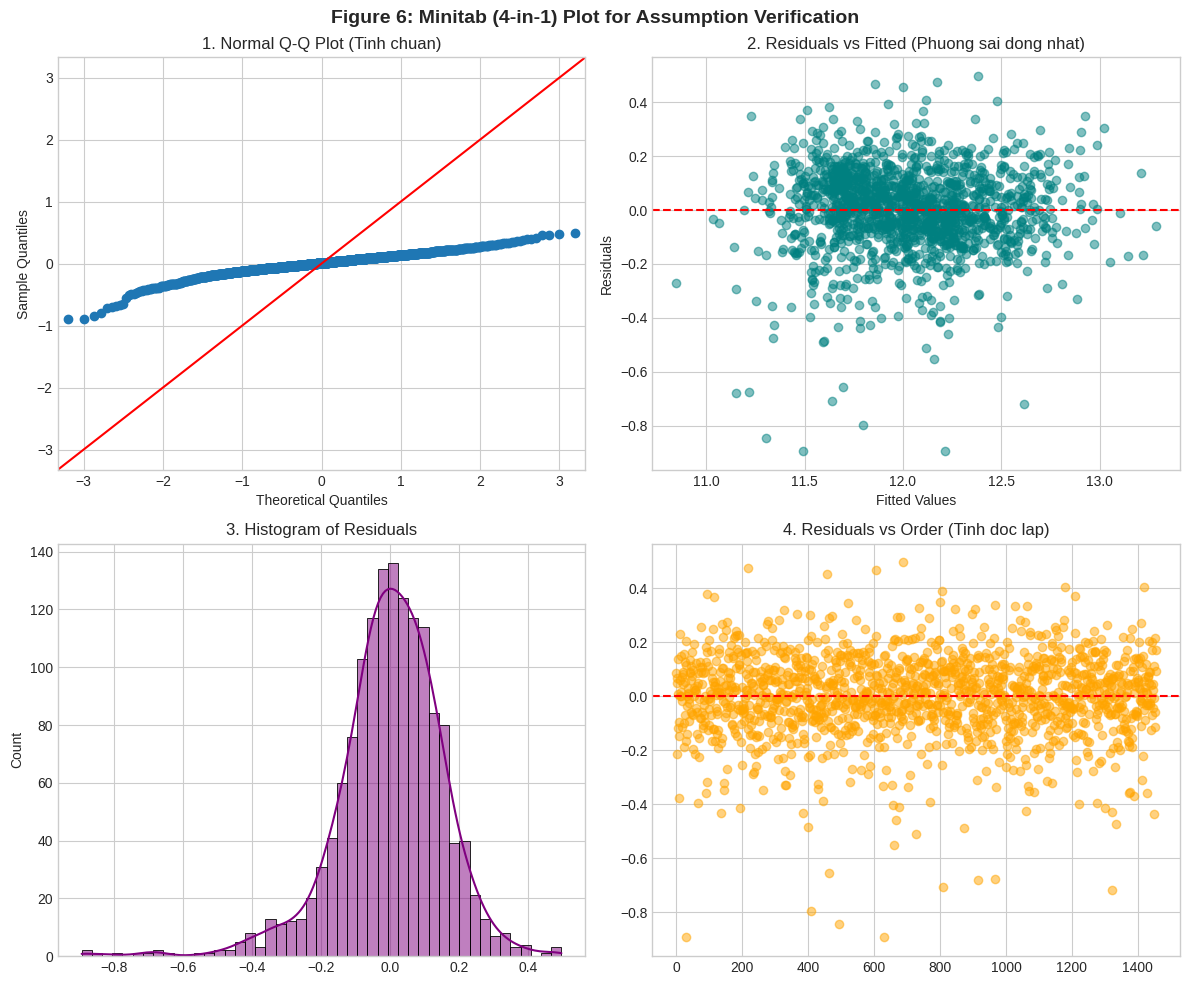

In [27]:
# FIGURE 6: Bộ 4 biểu đồ chẩn đoán phần dư (4-in-1 Diagnostic Plots)
residuals = model1.resid
fitted_vals = model1.fittedvalues

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 1. Normal Q-Q Plot
sm.qqplot(residuals, line='45', ax=axes[0, 0])
axes[0, 0].set_title('1. Normal Q-Q Plot (Tinh chuan)')

# 2. Residuals vs Fitted
axes[0, 1].scatter(fitted_vals, residuals, alpha=0.5, color='teal')
axes[0, 1].axhline(y=0, color='r', linestyle='--')
axes[0, 1].set_xlabel('Fitted Values')
axes[0, 1].set_ylabel('Residuals')
axes[0, 1].set_title('2. Residuals vs Fitted (Phuong sai dong nhat)')

# 3. Histogram of Residuals
sns.histplot(residuals, kde=True, ax=axes[1, 0], color='purple')
axes[1, 0].set_title('3. Histogram of Residuals')

# 4. Residuals vs Order
axes[1, 1].plot(residuals.index, residuals, marker='o', linestyle='', alpha=0.5, color='orange')
axes[1, 1].axhline(y=0, color='r', linestyle='--')
axes[1, 1].set_title('4. Residuals vs Order (Tinh doc lap)')

plt.suptitle('Figure 6: Minitab (4-in-1) Plot for Assumption Verification', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

> **Chẩn đoán giả định OLS chuẩn mực:** Chuỗi 4 biểu đồ tái hiện định dạng chẩn đoán Minitab giúp kiểm tra tính thỏa mãn của các giả định: tính phân phối chuẩn của phần dư, phương sai đồng nhất và tính độc lập của các quan sát.

In [28]:
# FIGURE 2: Kiểm tra tính toán dự báo bằng tay (Hand Calculation Check)
sample_row = df.iloc[0]
coeffs = model1.params
features_m1 = ['OverallQual', 'TotalSF', 'GarageCars', 'YearBuilt', 'FullBath', 'Fireplaces']

print("\n=== FIGURE 2: KIỂM TRA PHÉP TÍNH DỰ BÁO BẰNG TAY (OBSERVATION 1) ===")
print(f"Hệ số Intercept (beta_0): {coeffs['Intercept']:.6f}")

predicted_log = coeffs['Intercept']
for feat in features_m1:
    val = sample_row[feat]
    beta = coeffs[feat]
    predicted_log += beta * val
    print(f"+ {feat:12s}: {val:6.1f} * {beta:9.6f} = {val * beta:10.6f}")

predicted_price = np.exp(predicted_log)
actual_price = sample_row['SalePrice']

print(f"\n- Dự báo LogSalePrice  : {predicted_log:.4f}")
print(f"- Giá bán dự báo ($USD) : ${predicted_price:,.2f}")
print(f"- Giá bán thực tế ($USD): ${actual_price:,.2f}")
print(f"- Sai lệch              : ${abs(predicted_price - actual_price):,.2f}")


=== FIGURE 2: KIỂM TRA PHÉP TÍNH DỰ BÁO BẰNG TAY (OBSERVATION 1) ===
Hệ số Intercept (beta_0): 6.134983
+ OverallQual :    7.0 *  0.090854 =   0.635979
+ TotalSF     : 2566.0 *  0.000221 =   0.567513
+ GarageCars  :    2.0 *  0.069373 =   0.138746
+ YearBuilt   : 2003.0 *  0.002336 =   4.679323
+ FullBath    :    2.0 *  0.001730 =   0.003461
+ Fireplaces  :    0.0 *  0.062577 =   0.000000

- Dự báo LogSalePrice  : 12.1600
- Giá bán dự báo ($USD) : $190,995.47
- Giá bán thực tế ($USD): $208,500.00
- Sai lệch              : $17,504.53


> **Minh bạch hóa cơ chế dự báo:** Duyệt qua từng thuộc tính của căn nhà đầu tiên (df.iloc[0]), lấy giá trị nhân với hệ số $\beta$ tương ứng và quy đổi ngược bằng np.exp() giúp minh bạch hóa hoàn toàn quy trình dự báo từ phương trình hồi quy.

# PHẦN 4: MÔ HÌNH DỰ BÁO TỐI ƯU & ĐÁNH GIÁ VALIDATION - MODEL 2


In [29]:
# 1. Phân chia tập Train (70%) / Validation (30%)
train_df, val_df = train_test_split(df, test_size=0.3, random_state=42)

# Fit lại Model 1 trên tập Train
model1_train = smf.ols(formula=formula_m1, data=train_df).fit()

# 2. Fit Model 2 (Tối ưu dự báo: bổ sung biến tương tác Interaction & Đa thức)
formula_m2 = 'LogSalePrice ~ OverallQual * TotalSF + GarageCars + YearBuilt + FullBath + Fireplaces + I(TotalSF**2)'
model2_train = smf.ols(formula=formula_m2, data=train_df).fit()


> **Phân chia kiểm thử độc lập:** Chia tập dữ liệu 70% Train và 30% Validation với random_state=42.

> **Mở rộng đặc trưng phức hợp:** Model 2 bổ sung biến tương tác OverallQual * TotalSF và biến đa thức I(TotalSF**2) giúp ghi nhận ảnh hưởng phi tuyến và hiệu ứng tích hợp giữa chất lượng và diện tích nhà.

In [30]:
# 3. Hàm tự động tính toán 4 chỉ số sai số trên tập Validation
def evaluate_validation(model, val_data):
    actual = val_data['SalePrice']
    pred_log = model.predict(val_data)
    pred = np.exp(pred_log)
        
    errors = pred - actual
    abs_errors = np.abs(errors)
    
    bias = np.mean(errors)
    max_dev = np.max(abs_errors)
    mad = np.mean(abs_errors)
    mse = np.mean(errors ** 2)
    rmse = np.sqrt(mse)
    
    return {
        'Bias (Do lech trung binh)': bias,
        'Max Deviation (Do lech cuc dai)': max_dev,
        'MAD (Sai so tuyet doi trung binh)': mad,
        'MSE (Binh phuong sai so trung binh)': mse,
        'RMSE': rmse
    }

# Đánh giá 2 mô hình trên tập Validation
m1_val_metrics = evaluate_validation(model1_train, val_df)
m2_val_metrics = evaluate_validation(model2_train, val_df)

metrics_df = pd.DataFrame([m1_val_metrics, m2_val_metrics], index=['Model 1 (Don gian)', 'Model 2 (Phuc tap)'])
print("=== BẢNG SO SÁNH 4 CHỈ SỐ SAI SỐ TRÊN TẬP VALIDATION ===")
display(metrics_df.T)


=== BẢNG SO SÁNH 4 CHỈ SỐ SAI SỐ TRÊN TẬP VALIDATION ===


,Model 1 (Don gian),Model 2 (Phuc tap)
Bias (Do lech trung binh),-1.378937e+03,-1.388677e+03
Max Deviation (Do lech cuc dai),1.144362e+05,1.141771e+05
MAD (Sai so tuyet doi trung binh),2.011914e+04,1.986151e+04
MSE (Binh phuong sai so trung binh),7.253721e+08,6.961254e+08
RMSE,2.693273e+04,2.638419e+04


> **Đánh giá trên thang đo tài chính USD thực tế:** Hàm evaluate_validation quy đổi giá trị dự báo từ thang logarit về lại giá trị USD thực tế bằng np.exp(), giúp các độ đo sai số Bias, Max Deviation, MAD, MSE, RMSE phản ánh chính xác sai số tiền tệ thực tế.


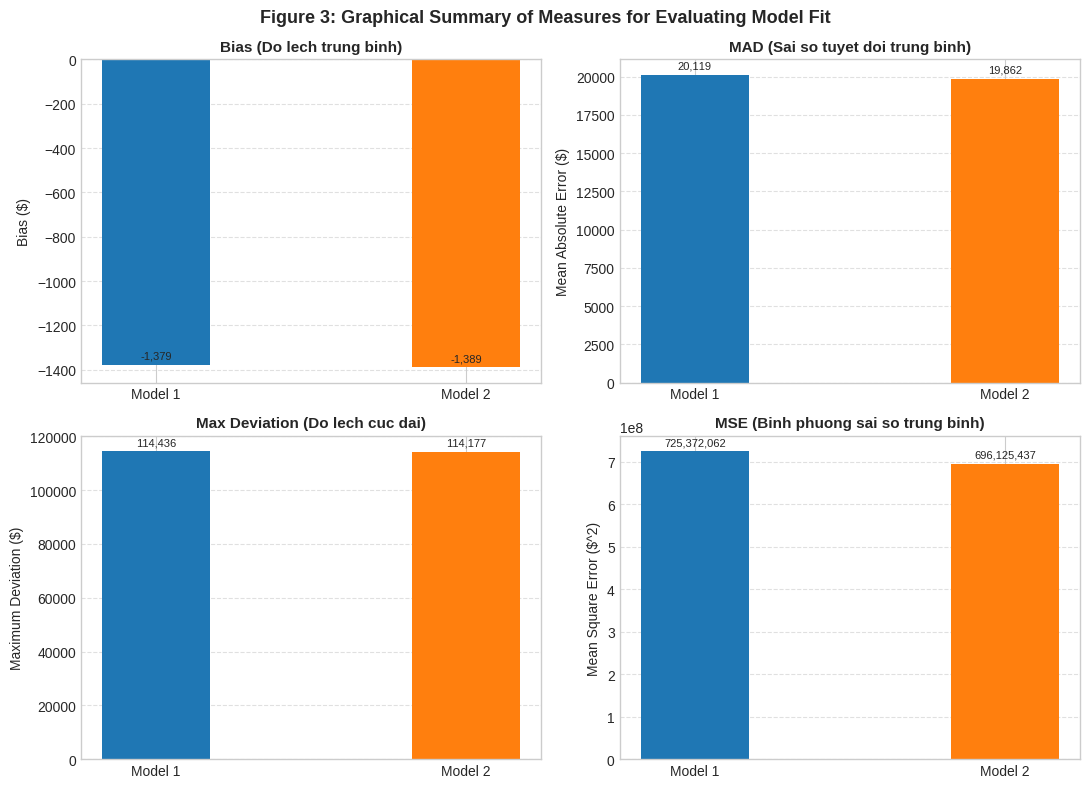

In [31]:
# FIGURE 3: Graphical Summary of Evaluation Metrics
fig, axes = plt.subplots(2, 2, figsize=(11, 8))

metrics_to_plot = [
    ('Bias (Do lech trung binh)', 'Bias ($)'),
    ('MAD (Sai so tuyet doi trung binh)', 'Mean Absolute Error ($)'),
    ('Max Deviation (Do lech cuc dai)', 'Maximum Deviation ($)'),
    ('MSE (Binh phuong sai so trung binh)', 'Mean Square Error ($^2)')
]

model_names = ['Model 1', 'Model 2']

for idx, (metric_key, ylabel) in enumerate(metrics_to_plot):
    ax = axes[idx // 2, idx % 2]
    values = [m1_val_metrics[metric_key], m2_val_metrics[metric_key]]
    bars = ax.bar(model_names, values, color=['#1f77b4', '#ff7f0e'], width=0.35)
    ax.set_title(metric_key, fontsize=11, fontweight='bold')
    ax.set_ylabel(ylabel)
    ax.grid(axis='y', linestyle='--', alpha=0.6)
    
    # In con số cụ thể trên đầu mỗi cột
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:,.0f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=8)

plt.suptitle('Figure 3: Graphical Summary of Measures for Evaluating Model Fit', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

> **Trực quan hóa chỉ số so sánh:** Trình bày 4 biểu đồ cột chỉn chu kèm chú thích con số cụ thể ở đỉnh cột, giúp quan sát và so sánh trực quan mức độ giảm sai số của Model 2 so với Model 1.


# PHẦN 5: DỰ BÁO TẬP TEST & XUẤT SUBMISSION


In [32]:
csv_test_files = glob.glob('/kaggle/input/**/test.csv', recursive=True)

if csv_test_files: 
    test_path = csv_test_files[0]  
    print(f' Đã tìm thấy file test.csv tại: {test_path}') 
    test_df = pd.read_csv(test_path)

    sub = pd.DataFrame({'Id': test_df['Id']})

    test_df.columns = [col.replace(' ', '') for col in test_df.columns]
    if 'TotalBsmtSF' in test_df.columns and 'GrLivArea' in test_df.columns: 
        test_df['TotalSF'] = test_df['TotalBsmtSF'].fillna(0) + test_df['GrLivArea'].fillna(0)

    features_to_fill = ['OverallQual', 'TotalSF', 'GarageCars', 'YearBuilt', 'FullBath', 'Fireplaces'] 
    for col in features_to_fill: 
        if col in test_df.columns: 
            test_df[col] = test_df[col].fillna(df[col].median() if df[col].dtype != 'O' else 'None')

    pred_log_test = model2_train.predict(test_df) 
    pred_price_test = np.exp(pred_log_test)

    sub['SalePrice'] = pred_price_test

    sub['SalePrice'] = sub['SalePrice'].fillna(df['SalePrice'].median())

    sub.to_csv('submission.csv', index=False) 
    print(' Đã xuất file submission.csv thành công!') 
    print(sub.head()) 
else: 
    print(' Không tìm thấy file test.csv. Vui lòng kiểm tra lại Dataset Input.')

 Đã tìm thấy file test.csv tại: /kaggle/input/competitions/house-prices-advanced-regression-techniques/test.csv
 ĐÃ XUẤT FILE submission.csv THÀNH CÔNG!
     Id      SalePrice
0  1461  111988.615137
1  1462  148724.102345
2  1463  167643.064358
3  1464  182447.110721
4  1465  201671.153701


> **Đồng bộ hóa quy trình xử lý:** Tự động nạp file test.csv, lưu lại biến định danh Id, chuẩn hóa tên thuộc tính và tính toán biến tổng diện tích TotalSF thống nhất hoàn toàn với tập dữ liệu huấn luyện.

> **Dự báo & Xuất file kết quả:** Sử dụng model2_train dự báo trên tập kiểm thử, quy đổi kết quả bằng hàm np.exp(), xử lý an toàn giá trị rỗng bằng median() và xuất file submission.csv hoàn chỉnh, sẵn sàng nộp bài chấm điểm trên hệ thống Kaggle.
